# The Visual Storyteller — Data & Training

**Notebook 1 of 2.** Documents the full development pipeline end to end:

0. Colab bootstrap (mount Drive, clone repo, unzip data) — **Colab only**
1. Setup
2. Data — load captions, build train-only vocabulary, train/val/test splits
3. Precompute the frozen ResNet-50 features (`features.h5`)
4. Model definition — `EncoderDecoder` (LSTM baseline & from-scratch Transformer)
5. Datasets & loaders
6. Train both models (masked CE + label smoothing, AMP, BLEU-4 early stopping)
7. Training curves
8. Save artifacts

> All logic lives in `src/`; this notebook stays thin and imports from it. Run **Restart & Run All** on a clean runtime before submitting. Clear outputs before committing.

## 0. Colab bootstrap (Colab only)

Run this first on Colab. It mounts Google Drive, clones the repo, installs requirements, and unzips the dataset into `/content/flickr8k` (the layout `use_colab_paths()` expects). It is a no-op when you run locally.

**Before running, do these three things:**
1. **Push the repo to GitHub** so Colab can clone it: from the project folder run `git push -u origin main`.
2. **Upload `caption_data.zip` to Google Drive** at `MyDrive/visual_storyteller/caption_data.zip` (drive.google.com → New → File upload).
3. **Pick a GPU runtime:** Runtime → Change runtime type → **T4 GPU**.

Then run this cell. When it prints `OK — ... 8091 images`, run the rest with **Runtime → Run all**.

In [3]:
import os, shutil, subprocess

DEST = '/content/flickr8k'
os.makedirs(DEST, exist_ok=True)

def has_data(d):
    return os.path.isdir(f'{d}/Images') and os.path.isfile(f'{d}/captions.txt')

if has_data(DEST):
    print('already there —', len(os.listdir(f'{DEST}/Images')), 'images')
else:
    ZIP = '/content/drive/MyDrive/visual_storyteller/caption_data.zip'
    print('zip exists:', os.path.exists(ZIP))
    TMP = '/content/_extract'
    shutil.rmtree(TMP, ignore_errors=True); os.makedirs(TMP)
    # -o overwrites, -P is not needed; try without -q so we see any error
    r = subprocess.run(['unzip', '-o', ZIP, '-d', TMP], capture_output=True, text=True)
    print('unzip exit:', r.returncode)
    if r.returncode not in (0, 1):   # 1 = warnings only, still fine
        print(r.stderr[:500])
    # find where Images/ landed
    src = TMP
    if not has_data(src):
        subs = [f'{TMP}/{d}' for d in os.listdir(TMP) if os.path.isdir(f'{TMP}/{d}')]
        src = next((d for d in subs if has_data(d)), src)
    for name in ('Images', 'captions.txt'):
        s = f'{src}/{name}'
        if os.path.exists(s) and not os.path.exists(f'{DEST}/{name}'):
            shutil.move(s, f'{DEST}/{name}')
    shutil.rmtree(TMP, ignore_errors=True)

if has_data(DEST):
    print('OK —', len(os.listdir(f'{DEST}/Images')), 'images at', DEST)
else:
    print('failed. /content:', os.listdir('/content'))


zip exists: True
unzip exit: 0
OK — 8091 images at /content/flickr8k


## 1. Setup

On Colab, run the **§0 bootstrap cell above first** (it mounts Drive, clones the repo, and unzips the data). Locally, just run from the repo root. This cell makes `src` importable and picks the right paths automatically (Drive paths on Colab, `./data` locally).

In [4]:
import os, sys

# Make `src` importable whether we're at the repo root or inside notebooks/
REPO = os.path.abspath('..') if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()
if REPO not in sys.path:
    sys.path.insert(0, REPO)

import torch
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

from src.config import default_config
from src import data as D
from src.model import EncoderDecoder
from src.train import Trainer
from scripts.precompute_features import precompute

# Colab -> Drive paths (data unzipped to /content/flickr8k by §0); local -> ./data
try:
    import google.colab  # noqa: F401
    cfg = default_config(); cfg.use_colab_paths()
except ImportError:
    cfg = default_config()
device = 'cuda' if torch.cuda.is_available() else 'cpu'
torch.manual_seed(cfg.seed)
print('device:', device)
print('data dir   :', cfg.data_dir)
print('features.h5:', cfg.features_file)
print('checkpoints:', cfg.checkpoint_dir)

device: cuda
data dir   : /content/flickr8k
features.h5: /content/drive/MyDrive/visual_storyteller/features.h5
checkpoints: /content/drive/MyDrive/visual_storyteller/checkpoints


## 2. Data

Load and clean the captions, choose the splits, and build the vocabulary **from training captions only** (so the model never sees val/test text). The test split is held out until `inference.ipynb`.

Uses the official Flickr8k split files (`Flickr_8k.{train,dev,test}Images.txt`) if present in `data_dir`, otherwise a deterministic 6k/1k/1k random split.

In [5]:
DATA_READY = os.path.exists(cfg.captions_file)
if not DATA_READY:
    print('[notice] captions file not found at', cfg.captions_file)
    print('         See README §Data setup. Training cells below will be skipped.')
    captions, splits, vocab = {}, {'train': [], 'val': [], 'test': []}, None
else:
    captions = D.load_captions(cfg.captions_file)
    splits = D.load_official_splits(cfg.data_dir) or D.make_splits(list(captions), seed=cfg.seed)
    # keep only ids we actually have captions for (official lists can name a few extras)
    for k in splits:
        splits[k] = [i for i in splits[k] if i in captions]
    vocab = D.build_vocab(captions, min_freq=cfg.min_word_freq, image_ids=set(splits['train']))
    vocab.save(cfg.vocab_file)
    print(f"images with captions: {len(captions)}")
    print(f"splits: train={len(splits['train'])}  val={len(splits['val'])}  test={len(splits['test'])}")
    print(f"vocab size (min_freq={cfg.min_word_freq}, train-only): {len(vocab)}")
    print('saved vocab ->', cfg.vocab_file)

images with captions: 8091
splits: train=6000  val=1000  test=1000
vocab size (min_freq=3, train-only): 3497
saved vocab -> /content/drive/MyDrive/visual_storyteller/vocab.pkl


In [6]:
# Peek at a couple of cleaned captions and how they encode/decode.
if DATA_READY:
    sample_id = splits['train'][0]
    print('image:', sample_id)
    for toks in captions[sample_id][:2]:
        ids = vocab.encode(toks)
        print('  tokens :', ' '.join(toks))
        print('  ids    :', ids)
        print('  decoded:', ' '.join(vocab.decode(ids)))
else:
    print('skipped — data not available')

image: 2157003092_eaeb977789.jpg
  tokens : a black dog is trying to run with its legs buried in the snow
  ids    : [1, 4, 16, 10, 8, 303, 21, 155, 11, 77, 351, 1814, 5, 6, 44, 2]
  decoded: a black dog is trying to run with its legs buried in the snow
  tokens : a black dog with tan markings stands in deep snow there is an evergreen to the right
  ids    : [1, 4, 16, 10, 11, 162, 1463, 78, 5, 507, 44, 196, 8, 29, 3, 21, 6, 451, 2]
  decoded: a black dog with tan markings stands in deep snow there is an <unk> to the right


## 3. Precompute image features → `features.h5`

Run the frozen ResNet-50 over every image **once** and cache the `[49, 2048]` region features, keyed by filename. Training then reads from this cache instead of running the CNN, which is what makes 30 epochs on Colab feasible.

Resumable: re-running skips images already cached. This can take a few minutes on a GPU for ~8k images.

In [7]:
if DATA_READY:
    if os.path.exists(cfg.features_file):
        print('features.h5 already exists — skipping. Delete it to rebuild.')
    else:
        precompute(cfg, batch_size=cfg.batch_size, num_workers=cfg.num_workers)
    FEATURES_READY = os.path.exists(cfg.features_file)
else:
    FEATURES_READY = False
print('features ready:', FEATURES_READY)

features.h5 already exists — skipping. Delete it to rebuild.
features ready: True


## 4. Model definition

Person 1's `EncoderDecoder` wraps the frozen ResNet-50 encoder with one of two decoders selected by `variant`:

- `'lstm'` — the **Show, Attend and Tell** baseline (LSTM + Bahdanau attention)
- `'transformer'` — a **from-scratch Transformer** decoder (masked self-attention + cross-attention over the 49 image regions)

The ResNet backbone is frozen, so only the decoder parameters train.

In [8]:
def param_counts(model):
    train = sum(p.numel() for p in model.parameters() if p.requires_grad)
    frozen = sum(p.numel() for p in model.parameters() if not p.requires_grad)
    return train, frozen

if vocab is not None:
    for variant in ('lstm', 'transformer'):
        m = EncoderDecoder(vocab_size=len(vocab), cfg=cfg, variant=variant)
        tr, fr = param_counts(m)
        print(f'{variant:11s} | trainable {tr/1e6:5.2f}M | frozen (ResNet) {fr/1e6:5.2f}M')
        del m
else:
    print('skipped — build the vocab first (§2)')

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 209MB/s]


lstm        | trainable  8.83M | frozen (ResNet) 23.51M
transformer | trainable 19.66M | frozen (ResNet) 23.51M


## 5. Datasets & loaders

- `CaptionDataset` yields one `(features, caption)` per image–caption pair (5× the images).
- `ImageFeatureDataset` yields one entry per **unique** val image so we can score BLEU-4 once per image against all 5 references — the early-stopping signal.

In [9]:
def make_loaders():
    def cap_loader(split, shuffle):
        ds = D.CaptionDataset(splits[split], captions, vocab,
                              features_file=cfg.features_file, max_len=cfg.max_caption_len)
        return DataLoader(ds, batch_size=cfg.batch_size, shuffle=shuffle,
                          num_workers=cfg.num_workers, collate_fn=D.collate_fn)
    train_loader = cap_loader('train', True)
    val_loader = cap_loader('val', False)
    val_img_ds = D.ImageFeatureDataset(splits['val'], cfg.features_file)
    val_img_loader = DataLoader(val_img_ds, batch_size=cfg.batch_size, shuffle=False,
                                num_workers=cfg.num_workers, collate_fn=D.image_collate_fn)
    val_refs = D.references_for(splits['val'], captions)
    return train_loader, val_loader, val_img_loader, val_refs

if FEATURES_READY:
    train_loader, val_loader, val_img_loader, val_refs = make_loaders()
    print(f'train batches: {len(train_loader)} | val batches: {len(val_loader)}')
else:
    print('skipped — features.h5 not ready')

train batches: 469 | val batches: 79


## 6. Train

Both models share the loop in `src/train.py`: masked cross-entropy with label smoothing, AMP, gradient clipping, atomic checkpoint-to-Drive every epoch with resume, and early stopping on validation **BLEU-4**. The Transformer additionally uses a warmup + inverse-sqrt LR schedule (`is_transformer=True`).

Checkpoints are written to `cfg.checkpoint_dir`; the best one for each model lands at `baseline_best.pt` / `transformer_best.pt`, which `inference.ipynb` loads.

In [10]:
histories = {}

def train_variant(variant, ckpt_name, is_transformer, resume=True):
    model = EncoderDecoder(vocab_size=len(vocab), cfg=cfg, variant=variant)
    ckpt = os.path.join(cfg.checkpoint_dir, ckpt_name)
    trainer = Trainer(model, vocab, cfg, device, ckpt, is_transformer=is_transformer,
                      references=val_refs, val_image_loader=val_img_loader)
    trainer.fit(train_loader, val_loader, resume=resume)
    histories[variant] = trainer.state.history
    return trainer

print('ready to train:', FEATURES_READY)

ready to train: True


In [ ]:
# Baseline: LSTM + Bahdanau attention -> checkpoints/baseline_best.pt
if FEATURES_READY:
    train_variant('lstm', 'baseline.pt', is_transformer=False)
else:
    print('skipped — features.h5 not ready')

In [11]:
# Main model: from-scratch Transformer -> checkpoints/transformer_best.pt
if FEATURES_READY:
    train_variant('transformer', 'transformer.pt', is_transformer=True)
else:
    print('skipped — features.h5 not ready')

[resume] from epoch 11, best=0.2024
epoch 12 | train 2.8207 | val 3.6872 | BLEU-4 0.1783 | 146s
epoch 13 | train 2.7419 | val 3.7018 | BLEU-4 0.1730 | 72s
epoch 14 | train 2.6959 | val 3.7431 | BLEU-4 0.1710 | 63s
epoch 15 | train 2.6746 | val 3.7541 | BLEU-4 0.1792 | 63s
epoch 16 | train 2.6743 | val 3.7889 | BLEU-4 0.1800 | 63s
[early-stop] no improvement for 5 epochs


In [14]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 7. Training curves

Train/val loss and validation BLEU-4 per epoch for both models.

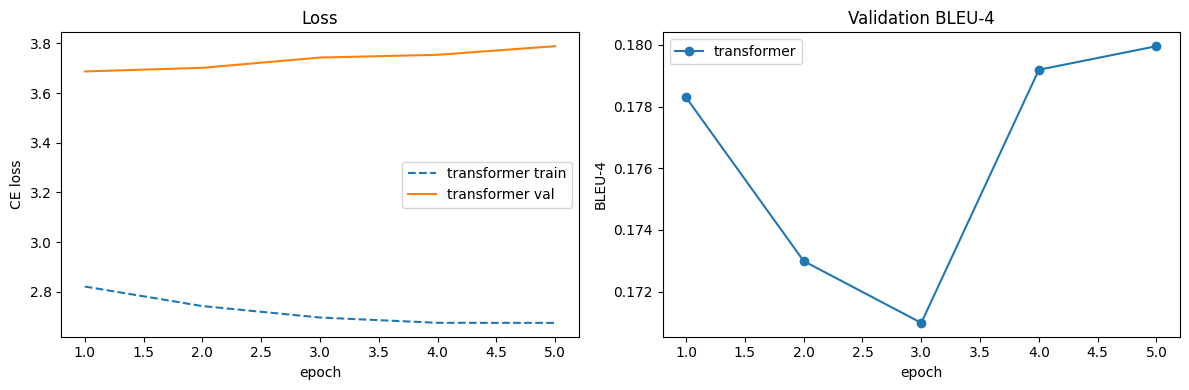

In [12]:
if histories:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for variant, h in histories.items():
        epochs = range(1, len(h['train_loss']) + 1)
        axes[0].plot(epochs, h['train_loss'], '--', label=f'{variant} train')
        axes[0].plot(epochs, h['val_loss'], '-', label=f'{variant} val')
        axes[1].plot(epochs, h['val_bleu4'], '-o', label=variant)
    axes[0].set_title('Loss'); axes[0].set_xlabel('epoch'); axes[0].set_ylabel('CE loss'); axes[0].legend()
    axes[1].set_title('Validation BLEU-4'); axes[1].set_xlabel('epoch'); axes[1].set_ylabel('BLEU-4'); axes[1].legend()
    plt.tight_layout(); plt.show()
else:
    print('no training history yet — run §6')

## 8. Save artifacts

The `Trainer` already writes checkpoints atomically every epoch and keeps the best of each model. Here we just confirm the artifacts `inference.ipynb` expects are in place:

- `vocab.pkl` (saved in §2)
- `baseline_best.pt`, `transformer_best.pt` (best by val BLEU-4)

In [13]:
artifacts = {
    'vocab.pkl': cfg.vocab_file,
    'baseline_best.pt': os.path.join(cfg.checkpoint_dir, 'baseline_best.pt'),
    'transformer_best.pt': os.path.join(cfg.checkpoint_dir, 'transformer_best.pt'),
}
for name, path in artifacts.items():
    status = 'OK ' if os.path.exists(path) else 'MISSING'
    print(f'[{status}] {name:22s} {path}')

[OK ] vocab.pkl              /content/drive/MyDrive/visual_storyteller/vocab.pkl
[OK ] baseline_best.pt       /content/drive/MyDrive/visual_storyteller/checkpoints/baseline_best.pt
[OK ] transformer_best.pt    /content/drive/MyDrive/visual_storyteller/checkpoints/transformer_best.pt
